# Métricas relacionales sobre el grafo Cora

## Objetivo

En el notebook anterior se realizó una exploración inicial del conjunto de datos Cora y se construyó el grafo de citaciones correspondiente. Cada nodo del grafo representa un artículo científico y cada arista representa una relación de citación entre artículos.

El objetivo de este notebook es extraer características relacionales de los nodos mediante técnicas de análisis de redes. Estas características permitirán describir la posición y relevancia de cada artículo dentro de la estructura del grafo.

En particular, se calcularán diversas métricas relacionales como el grado, distintas medidas de centralidad, el coeficiente de agrupamiento (clustering coefficient), PageRank y la pertenencia a comunidades. Posteriormente, estas métricas se utilizarán como variables de entrada para los modelos de clasificación que se desarrollarán en fases posteriores del proyecto.

Al finalizar este notebook se obtendrá un conjunto de datos enriquecido donde cada artículo estará representado mediante sus propiedades relacionales y su categoría temática asociada.

Se seguirá el siguiente orden:
1. Introducción
2. Carga de datos
3. Reconstrucción del grafo
4. Degree y Degree Centrality
5. Betweenness Centrality
6. Closeness Centrality
7. Clustering Coefficient
8. PageRank
9. Detección de comunidades (Louvain)
10. Construcción del DataFrame final
11. Conclusiones

## Carga de los datos

Se cargan los ficheros originales del conjunto de datos Cora. El fichero `cora.content` contiene la información de los artículos y sus atributos, mientras que `cora.cites` almacena las relaciones de citación entre ellos.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [3]:
contenido = pd.read_csv("../data/raw/cora.content", sep="\t", header=None)
contenido.head()
# la columna 0 se corresponde al id del nodo, las columnas 1 a 1433 corresponden al los atriibutos 
# de palabra y la columna 1434 se corresponde a la clase a la que pertenece cada nodo

,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [4]:
citas = pd.read_csv("../data/raw/cora.cites", sep="\t", header=None)
citas.head()
# primera columna es el articulo citado y la segunda el que lo cita 

,0,1
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


A continuación, hacemos el mismo renombrado que en el notebook anterior.

In [5]:
num_features = contenido.shape[1] - 2 # nos da el numero de columnas de las palabras

columnas = ["articulo_id"] + [f"palabra_{i}" for i in range(num_features)] + ["clase"]

contenido.columns = columnas

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [6]:
citas.columns = ["articulo_citado_id", "articulo_citante_id"]

citas.head()

,articulo_citado_id,articulo_citante_id
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## Guardado de los datos procesados

Una vez renombradas las columnas de los archivos originales, guardamos una versión procesada de `cora.content` y `cora.cites` en la carpeta `data/processed`.

De esta forma, en los siguientes notebooks podremos cargar directamente los datos con nombres de columnas descriptivos, sin tener que repetir el proceso de renombrado cada vez.

In [60]:
contenido.to_csv("../data/processed/cora_content_procesado.csv", index=False)
citas.to_csv("../data/processed/cora_cites_procesado.csv", index=False)

## Reconstrucción del grafo

A partir de las relaciones de citación se reconstruye el grafo utilizado en el análisis. Se empleará principalmente una versión no dirigida del grafo para el cálculo de las métricas relacionales.

In [7]:
G_directed = nx.from_pandas_edgelist(
    citas,
    source="articulo_citante_id",
    target="articulo_citado_id",
    create_using=nx.DiGraph()
)

print("Número de nodos:", G_directed.number_of_nodes())
print("Número de aristas:", G_directed.number_of_edges())

Número de nodos: 2708
Número de aristas: 5429


In [8]:
for _, fila in contenido.iterrows():

    articulo = fila["articulo_id"]

    G_directed.nodes[articulo]["clase"] = fila["clase"]

In [9]:
primer_nodo = list(G_directed.nodes())[0]

print(G_directed.nodes[primer_nodo])

{'clase': 'Genetic_Algorithms'}


In [10]:
G = G_directed.to_undirected()

In [11]:
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

Nodos: 2708
Aristas: 5278


## Degree y Degree Centrality

El grado de un nodo representa el número de conexiones que tiene con otros nodos del grafo. En el contexto del conjunto de datos Cora, el grado de un artículo indica cuántas relaciones de citación mantiene con otros artículos de la red.

Por otro lado, la centralidad de grado (Degree Centrality) es una versión normalizada del grado que permite comparar la importancia relativa de los nodos dentro de la red. Los nodos con valores elevados suelen ocupar posiciones más conectadas y potencialmente más relevantes dentro de la estructura del grafo.

Estas métricas constituyen una primera aproximación a la caracterización relacional de los artículos científicos.


In [12]:
degree = dict(G.degree())

print("Número de nodos analizados:", len(degree))

Número de nodos analizados: 2708


Algunos ejemplos:

In [13]:
list(degree.items())[:10]

[(1033, 5),
 (35, 168),
 (103482, 6),
 (103515, 11),
 (1050679, 4),
 (1103960, 5),
 (1103985, 2),
 (1109199, 3),
 (1112911, 4),
 (1113438, 5)]

Estadísticas del degree:

In [14]:
degree_series = pd.Series(degree)

degree_series.describe()

count    2708.000000
mean        3.898080
std         5.228784
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       168.000000
dtype: float64

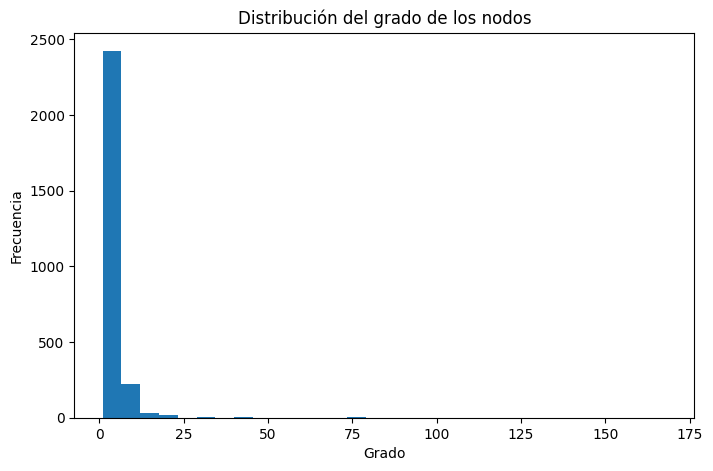

In [15]:
plt.figure(figsize=(8,5))

plt.hist(degree_series, bins=30)

plt.title("Distribución del grado de los nodos")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")

plt.savefig("../reports/degree_histograma.png")
plt.show()

Ahora, vamos a calcular la versión normalizada, siguiendo el mismo proceso.

In [16]:
degree_centrality = nx.degree_centrality(G)

print("Número de nodos analizados:",
      len(degree_centrality))

Número de nodos analizados: 2708


In [17]:
degree_centrality_series = pd.Series(
    degree_centrality
)

degree_centrality_series.describe()

count    2708.000000
mean        0.001440
std         0.001932
min         0.000369
25%         0.000739
50%         0.001108
75%         0.001847
max         0.062061
dtype: float64

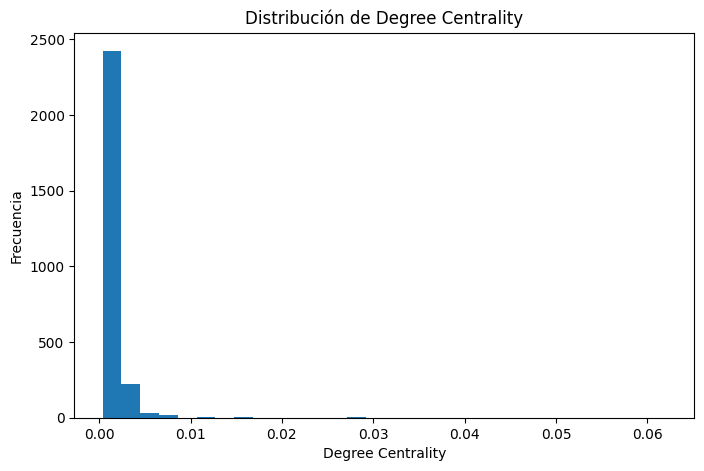

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    degree_centrality_series,
    bins=30
)

plt.title(
    "Distribución de Degree Centrality"
)

plt.xlabel("Degree Centrality")
plt.ylabel("Frecuencia")

plt.savefig("../reports/central_degree_histograma.png")
plt.show()

A partir de aquí empezaremos a construir el dataset final.

In [19]:
metricas_df = pd.DataFrame({
    "articulo_id": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "degree_centrality":
        [degree_centrality[n] for n in G.nodes()]
})
metricas_df.head()

,articulo_id,degree,degree_centrality
0,1033,5,0.001847
1,35,168,0.062061
2,103482,6,0.002216
3,103515,11,0.004064
4,1050679,4,0.001478


### Interpretación del grado

La distribución del grado presenta una marcada asimetría. Aunque el grado medio es aproximadamente 3.9 conexiones por nodo, la mayoría de los artículos poseen muy pocas relaciones de citación. De hecho, el 75% de los nodos tienen un grado igual o inferior a 5.

Sin embargo, existen algunos artículos excepcionalmente conectados, alcanzando un grado máximo de 168. Este comportamiento es característico de las redes de citación científicas, donde un reducido número de publicaciones actúan como referencias importantes y concentran un gran número de conexiones dentro de la red.


## Betweenness Centrality

La betweenness centrality, o centralidad de intermediación, mide la importancia de un nodo según la cantidad de caminos más cortos entre otros nodos que pasan por él.

En el contexto del dataset Cora, un artículo con alta betweenness centrality puede interpretarse como un artículo que actúa como puente entre distintas zonas del grafo de citaciones. Es decir, puede conectar comunidades o grupos de artículos que, de otra forma, estarían menos relacionados.

Esta métrica puede ser útil para la clasificación porque algunos artículos pueden ocupar posiciones estructurales diferentes dependiendo de su categoría temática.

In [20]:
betweenness_centrality = nx.betweenness_centrality(G)

print("Número de nodos analizados:", len(betweenness_centrality))

Número de nodos analizados: 2708


Estadísticas de betweenness centrality:

In [21]:
betweenness_series = pd.Series(betweenness_centrality)

betweenness_series.describe()

count    2708.000000
mean        0.001653
std         0.006941
min         0.000000
25%         0.000000
50%         0.000255
75%         0.001299
max         0.232488
dtype: float64

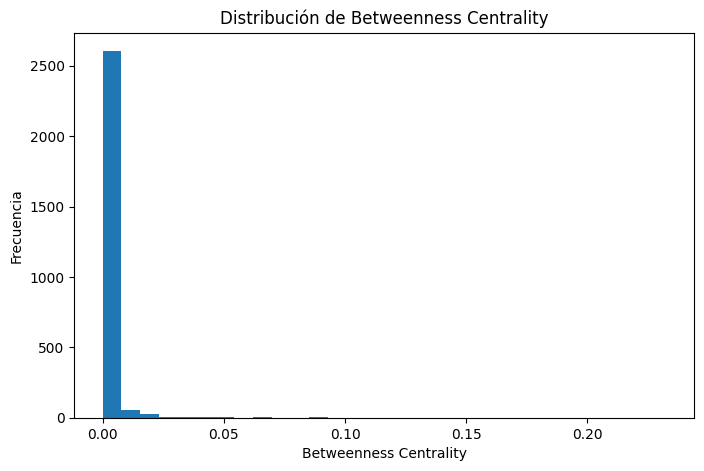

In [22]:
plt.figure(figsize=(8,5))

plt.hist(betweenness_series, bins=30)

plt.title("Distribución de Betweenness Centrality")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frecuencia")

plt.savefig("../reports/betweenness_centrality_histograma.png")
plt.show()

A continuación analizamos y vemos cuales son los nodos que más actúan como puente:

In [23]:
top_betweenness = betweenness_series.sort_values(ascending=False).head(10)

top_betweenness

35      0.232488
3229    0.126101
4330    0.089344
1365    0.085341
6213    0.076375
887     0.067918
1272    0.063187
910     0.052489
3231    0.049843
6214    0.041250
dtype: float64

Para verlo mejor creamos una tabla que tambien muestre la clase de cada articulo:

In [24]:
top_betweenness_df = (
    top_betweenness
    .reset_index()
)

top_betweenness_df.columns = ["articulo_id", "betweenness_centrality"]

top_betweenness_df = top_betweenness_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

top_betweenness_df

,articulo_id,betweenness_centrality,clase
0,35,0.232488,Genetic_Algorithms
1,3229,0.126101,Neural_Networks
2,4330,0.089344,Probabilistic_Methods
3,1365,0.085341,Neural_Networks
4,6213,0.076375,Reinforcement_Learning
5,887,0.067918,Genetic_Algorithms
6,1272,0.063187,Theory
7,910,0.052489,Neural_Networks
8,3231,0.049843,Theory
9,6214,0.041250,Reinforcement_Learning


Ahora añadimos el betweenness centrality al metricas_df que es donde almacenamos todas las metricas de los datos de cora.

In [25]:
metricas_df["betweenness_centrality"] = [
    betweenness_centrality[n] for n in metricas_df["articulo_id"]
]

metricas_df.head()

,articulo_id,degree,degree_centrality,betweenness_centrality
0,1033,5,0.001847,0.002430
1,35,168,0.062061,0.232488
2,103482,6,0.002216,0.004510
3,103515,11,0.004064,0.001681
4,1050679,4,0.001478,0.024078


### Interpretación de Betweenness Centrality

Los resultados muestran que el nodo con mayor `betweenness_centrality` es el artículo `35`, con un valor de `0.232488`, perteneciente a la clase `Genetic_Algorithms`. Esto indica que dicho artículo actúa como un nodo puente importante dentro de la red de citaciones.

También aparecen otros nodos relevantes, como `3229` de la clase `Neural_Networks` y `4330` de la clase `Probabilistic_Methods`. La presencia de distintas clases entre los nodos con mayor betweenness sugiere que esta métrica no está asociada únicamente a una categoría concreta, sino que identifica artículos que conectan diferentes zonas del grafo.

Por tanto, la betweenness centrality puede ser una métrica útil para el modelo de clasificación, ya que aporta información sobre la importancia estructural de cada nodo dentro de la red, más allá de sus atributos propios o del número directo de conexiones.

## Closeness Centrality

La closeness centrality, o centralidad de cercanía, mide lo cerca que está un nodo del resto de nodos del grafo.

Un nodo tendrá un valor alto de closeness centrality si puede alcanzar al resto de nodos mediante caminos relativamente cortos. En el contexto del dataset Cora, esto puede interpretarse como artículos que ocupan una posición central dentro de la red de citaciones.

Esta métrica puede ser útil para la clasificación porque permite identificar artículos que están estructuralmente próximos a muchos otros artículos del grafo.

In [26]:
closeness_centrality = nx.closeness_centrality(G)

print("Número de nodos analizados:", len(closeness_centrality))

Número de nodos analizados: 2708


Estadisticas del closeness centrality:

In [27]:
closeness_series = pd.Series(closeness_centrality)

closeness_series.describe()

count    2708.000000
mean        0.137476
std         0.046967
min         0.000369
25%         0.129613
50%         0.149159
75%         0.165475
max         0.222769
dtype: float64

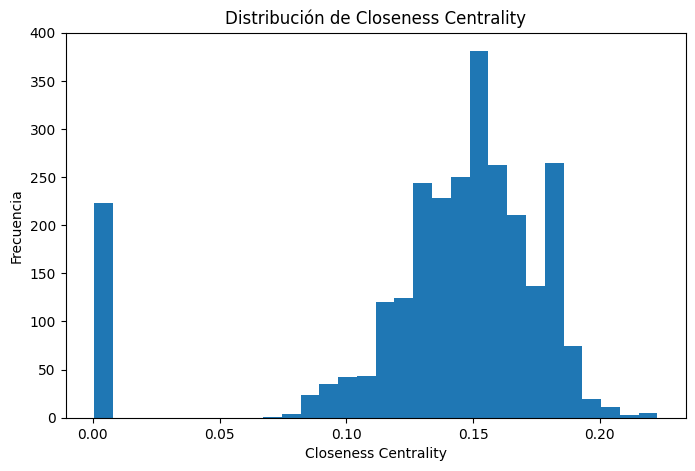

In [28]:
plt.figure(figsize=(8,5))

plt.hist(closeness_series, bins=30)

plt.title("Distribución de Closeness Centrality")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frecuencia")

plt.savefig("../reports/closeness_centrality_histograma.png")
plt.show()

A continuación vemos los 10 articulos con mayot closeness centrality:

In [29]:
top_closeness = closeness_series.sort_values(ascending=False).head(10)

top_closeness

35         0.222769
6213       0.221191
3229       0.219825
887        0.216013
4584       0.215952
6214       0.213384
1272       0.212449
6184       0.208848
4330       0.207631
1050679    0.207347
dtype: float64

In [30]:
top_closeness_df = top_closeness.reset_index()

top_closeness_df.columns = ["articulo_id", "closeness_centrality"]

top_closeness_df = top_closeness_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

top_closeness_df

,articulo_id,closeness_centrality,clase
0,35,0.222769,Genetic_Algorithms
1,6213,0.221191,Reinforcement_Learning
2,3229,0.219825,Neural_Networks
3,887,0.216013,Genetic_Algorithms
4,4584,0.215952,Reinforcement_Learning
5,6214,0.213384,Reinforcement_Learning
6,1272,0.212449,Theory
7,6184,0.208848,Reinforcement_Learning
8,4330,0.207631,Probabilistic_Methods
9,1050679,0.207347,Genetic_Algorithms


Por último añadimos la metrica de closeness_centrality a metricas_df

In [31]:
metricas_df["closeness_centrality"] = [
    closeness_centrality[n] for n in metricas_df["articulo_id"]
]

metricas_df.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality
0,1033,5,0.001847,0.002430,0.181710
1,35,168,0.062061,0.232488,0.222769
2,103482,6,0.002216,0.004510,0.186238
3,103515,11,0.004064,0.001681,0.180501
4,1050679,4,0.001478,0.024078,0.207347


### Interpretación de Closeness Centrality

La distribución de la `closeness_centrality` muestra que la mayoría de los nodos tienen valores entre `0.12` y `0.18`, lo que indica que gran parte de los artículos se encuentran relativamente cerca del resto de nodos del grafo. Sin embargo, también aparece un grupo de nodos con valores cercanos a `0`, que probablemente corresponden a artículos poco conectados o situados fuera de la componente principal de la red.

El artículo con mayor valor es el nodo `35`, con una closeness centrality de `0.222769`, perteneciente a la clase `Genetic_Algorithms`. También destacan los nodos `6213`, de `Reinforcement_Learning`, y `3229`, de `Neural_Networks`. Estos artículos pueden interpretarse como nodos centrales dentro del grafo, ya que están conectados al resto de la red mediante caminos relativamente cortos.

Entre los nodos con mayor closeness aparecen varias clases distintas, por lo que esta métrica no parece depender únicamente de una categoría concreta. Desde el punto de vista del aprendizaje automático relacional, puede ser una métrica útil porque aporta información sobre la posición global de cada artículo en la red de citaciones.

## Clustering Coefficient

El clustering coefficient, o coeficiente de agrupamiento, mide el grado en el que los vecinos de un nodo están conectados entre sí.

En el contexto del dataset Cora, un artículo tendrá un clustering coefficient alto si los artículos con los que está relacionado también están relacionados entre ellos. Esto puede indicar que el artículo pertenece a una zona temática muy cohesionada dentro del grafo de citaciones.

Esta métrica puede ser útil para la clasificación porque permite identificar nodos que forman parte de grupos o comunidades densamente conectadas.


In [32]:
clustering_coefficient = nx.clustering(G)

print("Número de nodos analizados:", len(clustering_coefficient))

Número de nodos analizados: 2708


Estadísticas del clustering coefficient:

In [33]:
clustering_series = pd.Series(clustering_coefficient)

clustering_series.describe()

count    2708.000000
mean        0.240673
std         0.322079
min         0.000000
25%         0.000000
50%         0.095238
75%         0.333333
max         1.000000
dtype: float64

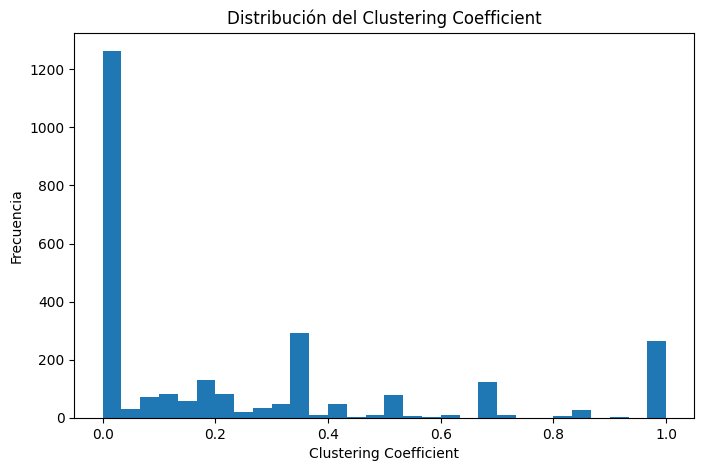

In [34]:
plt.figure(figsize=(8,5))

plt.hist(clustering_series, bins=30)

plt.title("Distribución del Clustering Coefficient")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Frecuencia")

plt.savefig("../reports/clustering_coefficient_histograma.png")
plt.show()

Ahora vemos los 10 articulos con mayor clustering coefficient:

In [35]:
top_clustering = clustering_series.sort_values(ascending=False).head(10)

top_clustering

1117219    1.0
753264     1.0
576973     1.0
1128208    1.0
1127430    1.0
1129027    1.0
1130847    1.0
1130856    1.0
739280     1.0
1136631    1.0
dtype: float64

In [36]:
top_clustering_df = top_clustering.reset_index()

top_clustering_df.columns = ["articulo_id", "clustering_coefficient"]

top_clustering_df = top_clustering_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

top_clustering_df = top_clustering_df.merge(
    metricas_df[["articulo_id", "degree"]],
    on="articulo_id",
    how="left"
)

top_clustering_df

,articulo_id,clustering_coefficient,clase,degree
0,1117219,1.0,Neural_Networks,2
1,753264,1.0,Theory,3
2,576973,1.0,Genetic_Algorithms,2
3,1128208,1.0,Genetic_Algorithms,2
4,1127430,1.0,Genetic_Algorithms,2
5,1129027,1.0,Genetic_Algorithms,2
6,1130847,1.0,Genetic_Algorithms,3
7,1130856,1.0,Genetic_Algorithms,2
8,739280,1.0,Neural_Networks,2
9,1136631,1.0,Theory,2


Por último añadimos la metrica de clustering_coefficient a metricas_df

In [37]:
metricas_df["clustering_coefficient"] = [
    clustering_coefficient[n] for n in metricas_df["articulo_id"]
]

metricas_df.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient
0,1033,5,0.001847,0.002430,0.181710,0.100000
1,35,168,0.062061,0.232488,0.222769,0.011406
2,103482,6,0.002216,0.004510,0.186238,0.133333
3,103515,11,0.004064,0.001681,0.180501,0.163636
4,1050679,4,0.001478,0.024078,0.207347,0.166667


### Interpretación del Clustering Coefficient

La distribución del `clustering_coefficient` muestra que una gran cantidad de nodos tienen un valor cercano a `0`. Esto indica que muchos artículos están conectados con otros artículos cuyos vecinos no están conectados entre sí, es decir, no forman grupos especialmente cohesionados dentro del grafo.

También se observa un conjunto de nodos con valores altos, incluso iguales a `1.0`. En estos casos, los vecinos del nodo están completamente conectados entre sí, por lo que estos artículos pertenecen a zonas localmente muy agrupadas o cerradas de la red de citaciones. Sin embargo, este valor debe interpretarse junto con el `degree`: un nodo puede tener `clustering_coefficient = 1.0` simplemente porque tiene pocos vecinos y todos ellos están conectados entre sí. Por tanto, un clustering alto indica cohesión local, pero no necesariamente importancia global dentro del grafo, sin embargo en la tabla de los 10 articulos con mayor clustering coefficient el degree no fluctua mucho.

En la tabla de los nodos con mayor clustering coefficient se incluye también el `degree` para comprobar cuántas conexiones tiene cada artículo. Además, aparecen artículos de distintas clases, como `Neural_Networks`, `Theory` y `Genetic_Algorithms`. Esto sugiere que la métrica no está asociada únicamente a una clase concreta, sino que describe el nivel de cohesión local de cada artículo dentro del grafo.

Desde el punto de vista del aprendizaje automático relacional, esta métrica puede ser útil porque permite diferenciar artículos situados en zonas muy cohesionadas de otros artículos más aislados o con conexiones menos agrupadas.

## PageRank

PageRank es una métrica que mide la importancia de un nodo dentro de un grafo teniendo en cuenta tanto sus conexiones como la relevancia de los nodos que apuntan hacia él.

En el contexto del dataset Cora, un artículo con PageRank alto puede interpretarse como un artículo relevante dentro de la red de citaciones, especialmente si es citado por otros artículos también importantes.

A diferencia del grado, que solo cuenta el número de conexiones, PageRank tiene en cuenta la estructura global del grafo y la importancia relativa de los nodos conectados. Por ello es muy importante aqui usar elk G_directed , es decir el grafo dirigido.

In [38]:
pagerank = nx.pagerank(G_directed)

print("Número de nodos analizados:", len(pagerank))

Número de nodos analizados: 2708


In [39]:
pagerank_series = pd.Series(pagerank)

pagerank_series.describe()

count    2708.000000
mean        0.000369
std         0.001077
min         0.000126
25%         0.000126
50%         0.000161
75%         0.000269
max         0.025159
dtype: float64

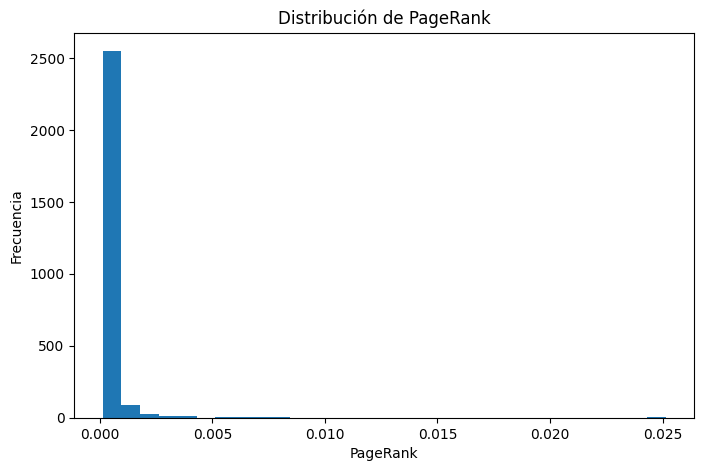

In [40]:
plt.figure(figsize=(8,5))

plt.hist(pagerank_series, bins=30)

plt.title("Distribución de PageRank")
plt.xlabel("PageRank")
plt.ylabel("Frecuencia")

plt.savefig("../reports/pagerank_histograma.png")
plt.show()

A continuación vemos los 10 articulos con mayor Page Rank

In [41]:
top_pagerank = pagerank_series.sort_values(ascending=False).head(10)

top_pagerank

35        0.025159
15429     0.024755
10177     0.024019
210871    0.011900
210872    0.009879
82920     0.008861
1365      0.008127
4584      0.007806
887       0.007400
643221    0.007000
dtype: float64

In [42]:
top_pagerank_df = top_pagerank.reset_index()

top_pagerank_df.columns = ["articulo_id", "pagerank"]

top_pagerank_df = top_pagerank_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

top_pagerank_df

,articulo_id,pagerank,clase
0,35,0.025159,Genetic_Algorithms
1,15429,0.024755,Theory
2,10177,0.024019,Theory
3,210871,0.011900,Genetic_Algorithms
4,210872,0.009879,Genetic_Algorithms
5,82920,0.008861,Genetic_Algorithms
6,1365,0.008127,Neural_Networks
7,4584,0.007806,Reinforcement_Learning
8,887,0.007400,Genetic_Algorithms
9,643221,0.007000,Probabilistic_Methods


Por último, añadimos la métrica de page rank a la tabla de metricas_df

In [43]:
metricas_df["pagerank"] = [
    pagerank[n] for n in metricas_df["articulo_id"]
]

metricas_df.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126


### Interpretación de PageRank

La distribución de `pagerank` muestra que la mayoría de los artículos tienen valores muy bajos, cercanos a `0`. Esto es normal, ya que PageRank reparte la importancia entre todos los nodos del grafo y solo unos pocos artículos concentran una relevancia claramente superior.

En la tabla de los nodos con mayor PageRank destaca el artículo `35`, con un valor de `0.025159`, perteneciente a la clase `Genetic_Algorithms`. También aparecen artículos como `15429` y `10177`, ambos de la clase `Theory`, con valores elevados de PageRank. Esto indica que estos artículos tienen una posición relevante dentro de la red de citaciones.

Además, entre los primeros resultados aparecen distintas clases, como `Genetic_Algorithms`, `Theory`, `Neural_Networks`, `Reinforcement_Learning` y `Probabilistic_Methods`. Esto sugiere que la importancia global medida por PageRank no se concentra únicamente en una categoría concreta.

Desde el punto de vista del aprendizaje automático relacional, PageRank puede ser una métrica útil porque aporta información sobre la relevancia global de cada artículo dentro del grafo. A diferencia del grado, no solo tiene en cuenta cuántas conexiones tiene un nodo, sino también la importancia de los nodos que lo citan.

## Detección de comunidades con Louvain

La detección de comunidades permite identificar grupos de nodos que están más conectados entre sí que con el resto del grafo.

En este trabajo se utiliza el algoritmo de Louvain, que busca particionar el grafo en comunidades maximizando la modularidad. En el contexto del dataset Cora, una comunidad puede interpretarse como un grupo de artículos científicos relacionados entre sí mediante citaciones.

Esta métrica puede ser útil para la clasificación, ya que los artículos que pertenecen a una misma comunidad pueden compartir temática o estar relacionados con categorías similares.

In [44]:
louvain_communities = nx.community.louvain_communities(G, seed=42)

print("Número de comunidades detectadas:", len(louvain_communities))

Número de comunidades detectadas: 104


Nos da 104 , porque son 104 listas de comunidades.

Para facilitar el uso de la metrica asignamos un id a cada comunidad:

In [45]:
louvain_partition = {}

for community_id, community_nodes in enumerate(louvain_communities):
    for node in community_nodes:
        louvain_partition[node] = community_id

print("Número de nodos con comunidad asignada:", len(louvain_partition))

Número de nodos con comunidad asignada: 2708


In [46]:
louvain_series = pd.Series(louvain_partition)

louvain_series.head()

58436      0
1128453    0
144679     0
463        0
801170     0
dtype: int64

A continuación vemos la cantidad de articulos en cada comunidad:

In [47]:
community_counts = louvain_series.value_counts().sort_index()

community_counts

0       13
1       29
2       20
3      185
4      124
      ... 
99       2
100      2
101      2
102      2
103      2
Name: count, Length: 104, dtype: int64

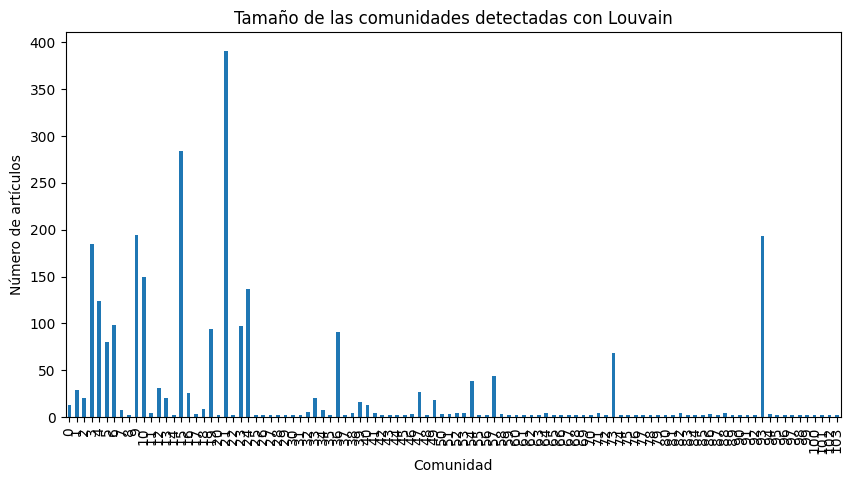

In [48]:
plt.figure(figsize=(10,5))

community_counts.plot(kind="bar")

plt.title("Tamaño de las comunidades detectadas con Louvain")
plt.xlabel("Comunidad")
plt.ylabel("Número de artículos")

plt.savefig("../reports/louvain_communities_sizes.png")
plt.show()

In [51]:
louvain_df = louvain_series.reset_index()
louvain_df.columns = ["articulo_id", "louvain_community"]

louvain_df = louvain_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

louvain_df.head()

,articulo_id,louvain_community,clase
0,58436,0,Case_Based
1,1128453,0,Genetic_Algorithms
2,144679,0,Case_Based
3,463,0,Case_Based
4,801170,0,Genetic_Algorithms


Por último añadimos la metrica de Louvain a metricas_df

In [52]:
metricas_df["louvain_community"] = [
    louvain_partition[n] for n in metricas_df["articulo_id"]
]

metricas_df.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212,21
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159,21
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497,3
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589,21
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126,21


### Interpretación de la detección de comunidades con Louvain

El algoritmo de Louvain ha detectado un total de `104` comunidades en el grafo, asignando correctamente una comunidad a los `2708` artículos del dataset.

En la gráfica se observa que el tamaño de las comunidades no es uniforme. Algunas comunidades contienen muchos artículos, llegando incluso a superar los `300` nodos, mientras que muchas otras comunidades son muy pequeñas, con pocos artículos. Esto indica que el grafo de Cora está formado por varios grupos grandes de artículos relacionados, junto con comunidades más reducidas o aisladas.

Desde el punto de vista del dataset, estas comunidades pueden interpretarse como grupos de artículos que están más conectados entre sí mediante citaciones. Por tanto, es posible que algunas comunidades estén relacionadas con determinadas categorías temáticas.

Para el aprendizaje automático relacional, la comunidad asignada por Louvain puede ser una característica útil, ya que resume información estructural del grafo y puede ayudar a los modelos de clasificación a identificar patrones entre la posición de un artículo en la red y su clase.

## Construcción del DataFrame final

Una vez calculadas todas las métricas relacionales, construimos el DataFrame final que se utilizará posteriormente para entrenar los modelos de clasificación.

Para ello, añadimos a `metricas_df` la clase real de cada artículo, obtenida del dataset original `cora.content`. De esta forma, cada fila representa un artículo, sus métricas relacionales dentro del grafo y la categoría temática que se intentará predecir.

In [54]:
datos_modelo = metricas_df.merge(
    contenido[["articulo_id", "clase"]],
    on="articulo_id",
    how="left"
)

datos_modelo.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community,clase
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212,21,Genetic_Algorithms
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159,21,Genetic_Algorithms
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497,3,Neural_Networks
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589,21,Genetic_Algorithms
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126,21,Genetic_Algorithms


Comprobamos el tamaño de la tabla de metricas que debe coincidir con el numero de nodos (articulos) originales es decir 2708

In [57]:
print("Tamaño de metricas_df:", metricas_df.shape)
print("Tamaño de datos_modelo:", datos_modelo.shape) # Este es el de las metricas pero con la clase incluida

Tamaño de metricas_df: (2708, 8)
Tamaño de datos_modelo: (2708, 9)


Por último guardamos la tabla de metricas como csv para poder usarla en los modelos predictivos.

In [59]:
datos_modelo.to_csv("../data/processed/cora_metricas_relacionales.csv", index=False)